# Collins / transversity: azimuthal-acceptance comparison

The SoLID 3He (neutron) Collins fit across **five** pseudodata configurations,
all generated in this repo and all fitted at 500 replicas, against the world-data
fit as the reference.

| key | run directory | acceptance | binning | bins |
|---|---|---|---|---|
| `world` | `../data_world` | existing world data — **the reference** | — | 146 rows |
| `sbs` | `../data_world` | SBS projection — a second external reference, **stat-only panel** | — | 455 rows |
| `phifull` | `data_phifull` | full 2π (100%) | own | 1660 |
| `phi4seg_fullbin` | `data_phi4seg24deg_phifullbin` | 4 × 24° (26.7% nominal), both arms | **reused from `phifull`** | 1660 |
| `phi4seg` | `data_phi4seg24deg` | 4 × 24°, both arms | own | 169 |
| `phi4segFA_fullbin` | `data_phi4seg24degFA_phifullbin` | 4 × 24°, **forward angle only** (large-angle e⁻ keeps full 2π) | **reused from `phifull`** | 1660 |
| `phi4segFA` | `data_phi4seg24degFA` | 4 × 24°, forward angle only | own | 239 |

**`_fullbin` versus own bins is not a detail.** A `_fullbin` run inherits
`phifull`'s 1660 bins, so its errors are comparable bin by bin; an own-bins run
re-bins under its own acceptance, trading fewer bins for more events in each. The
own-bins runs therefore look *better* than their `_fullbin` twins at equal
acceptance — that is bin width, not physics.

**The nominal coverage is not the event cost.** The cut applies to the electron
and the hadron alike, so a coincidence survives roughly 26.7² ≈ 7.1%; measured,
the median surviving yield is 4.8%. See `README.md` in this directory.

*(Rewritten 2026-08-31: the previous version read `outputcollins*` directories
and `tmdlib.tmd` from the upstream tree, and covered 6×24° and 4×12°FA
configurations that do not exist here.)*

**SBS is a reference, not a SoLID configuration.** It is an external projection with no systematics model of its own, so there is a single SBS fit rather than a stat/syst pair, and it is drawn in the **stat-only panel only** — absent from every stat+syst panel and table rather than repeated there unchanged. Fitted at 500 replicas like everything else, so its 3.2% replica-sampling noise is the same as the rest.


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath('..'))   # tmd.py lives at the repo root
import tmd

GALLERY = 'gallery'
os.makedirs(GALLERY, exist_ok=True)

Q2  = 2.4    # the single Q2 the gT figure and the ratio tables use
# The band figures draw every entry: the first carries the error band, any others
# would be central curves showing the Q2 evolution.
# One Q2. The machinery below still loops, so adding values back is a
# one-line change; with a single entry the band is drawn and nothing else.
Q2LIST = [2.4]
tol = 7.04   # the band-scale calibration; see check.md -- it cancels in every
             # error RATIO below, so the comparisons are insensitive to it

LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/CJ15lo/CJ15lo_0000.dat
CJ15lo PDF set, member #0, version 2; LHAPDF ID = 12300
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0211.dat
DSSFFlo PDF set, member #211, version 1; LHAPDF ID = 90211
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0321.dat
DSSFFlo PDF set, member #321, version 1; LHAPDF ID = 90321
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/NNPDFpol11_100/NNPDFpol11_100_0000.dat
NNPDFpol11_100 PDF set, member #0, version 1; LHAPDF ID = 251000


## Load fit results

Each file is the raw per-replica parameter table (50 rows x `Nu,Nd,a,b,c,kt2,chi2`).

In [2]:
STAT, SYST = 'out-enhanced3he_collins.dat', 'out-enhanced3hesyst_collins.dat'

# REF is the denominator of every error ratio below.
# The 4x-counts twins, derived from STAT/SYST rather than spelled out, so a change
# to the amplitude or the file naming carries through to both. They come from the
# fit scripts' -c 4 flag: the SoLID statistical error divided by sqrt(4), with the
# systematic budget left alone. For the *syst files the total error is REBUILT as
# sqrt(stat^2/4 + systabs^2 + AUT^2 systrel^2) rather than scaled whole -- more
# beam time does not shrink a systematic, and scaling error_tot would claim it does.
STAT_X4, SYST_X4 = (v.replace('.dat', '_x4counts.dat') for v in (STAT, SYST))

REF = 'world'

# Four curves and the world reference. The question here is narrow: what does the
# 4x24 deg phi cut cost at FOUR TIMES the counts, against the full-2pi run at its
# nominal luminosity, with SBS as the external yardstick.
#
# Deliberately absent, and where they live instead:
#   the R1 < 0.3 cut          -> a different question entirely
#   the 1x twins of the two phi-cut runs, and the 806-bin count binning
#                             -> plot-*_phicompare_x4counts.ipynb pairs 1x with 4x
#                                across four configurations; the binning scan is in
#                                plot-*_phicompare_morebin.ipynb
#
# 2pi and SBS stay at 1x on purpose. 2pi is the reference the phi cut is measured
# against, not a configuration whose luminosity is in question, and --counts never
# scales SBS at all: more SoLID beam time does not give SBS more events.
RUNS = {
    'world':             {'dir': '../data_world',
                          # the world fit has no stat/syst variants -- the same
                          # fit is the reference in both panels
                          'files': {'': 'out-world_collins.dat', 'syst': 'out-world_collins.dat'},
                          'label': r'$\rm world~data$',
                          'color': 'gray'},
    # one fit, no stat/syst split: no 'syst' key, so runs_for() leaves SBS out of
    # every stat+syst panel.
    'sbs':               {'dir': '../data_sbs',
                          'files': {'': 'out-sbs_collins.dat'},
                          'label': r'$\rm SBS$',
                          'color': 'saddlebrown'},
    'phifull':           {'dir': 'data_phifull',
                          'files': {'': STAT, 'syst': SYST},
                          'label': r'$\rm SoLID~full~2\pi$',
                          'color': 'black'},
    'phi4seg_fullbin_x4': {'dir': 'data_phi4seg24deg_phifullbin',
                          'files': {'': STAT_X4, 'syst': SYST_X4},
                          'label': r'$\rm 4\times24^\circ~(2\pi~bins,~4\times~counts)$',
                          'color': 'green'},
    # same 4x24 deg acceptance as above; 169 bins of its own rather than phifull's
    # 1660, so it shares no bin with the others -- compare the shape, never a value
    # at a given bin index.
    'phi4seg_x4':        {'dir': 'data_phi4seg24deg',
                          'files': {'': STAT_X4, 'syst': SYST_X4},
                          'label': r'$\rm 4\times24^\circ~(own~bins,~4\times~counts)$',
                          'color': 'darkorange'},
}
# 'sbs' is an external projection with no systematics model of its own: there is
# one SBS fit, not a stat/syst pair, so it belongs in the stat-only panel and
# nowhere else. The mechanism is the absence of a 'syst' entry in its `files` --
# every loop below iterates runs_for(suffix), so each run appears in exactly the
# panels it has a fit for. 'world' is the reference (the denominator of every
# ratio) and so carries both, pointing at the same file twice.
def runs_for(suffix):
    return [(run, cfg) for run, cfg in RUNS.items() if suffix in cfg['files']]

VARIANTS = ['', 'syst']

par = {}
for run, cfg in RUNS.items():
    for suf in VARIANTS:
        if suf not in cfg['files']:
            print(f'{run+suf:24s} {"-- no fit; absent from this panel":52s}')
            continue
        path = os.path.join(cfg['dir'], cfg['files'][suf])
        par[run + suf] = pd.read_csv(path, sep=r'\s+', index_col=False)
        print(f'{run+suf:24s} {path:56s} {len(par[run+suf])} replicas')


world                    ../data_world/out-world_collins.dat                      500 replicas
worldsyst                ../data_world/out-world_collins.dat                      500 replicas
sbs                      ../data_sbs/out-sbs_collins.dat                          500 replicas
sbssyst                  -- no fit; absent from this panel                   
phifull                  data_phifull/out-enhanced3he_collins.dat                 500 replicas
phifullsyst              data_phifull/out-enhanced3hesyst_collins.dat             500 replicas
phi4seg_fullbin_x4       data_phi4seg24deg_phifullbin/out-enhanced3he_collins_x4counts.dat 500 replicas
phi4seg_fullbin_x4syst   data_phi4seg24deg_phifullbin/out-enhanced3hesyst_collins_x4counts.dat 500 replicas
phi4seg_x4               data_phi4seg24deg/out-enhanced3he_collins_x4counts.dat   500 replicas
phi4seg_x4syst           data_phi4seg24deg/out-enhanced3hesyst_collins_x4counts.dat 500 replicas


### Fitted parameters, run by run

Mean ± std across replicas — a first look before propagating into $h_1$.

In [3]:
rows = []
for key, p in par.items():
    r = {'run': key}
    for c in p.columns:
        r[c] = f'{p[c].mean():.4f} +- {p[c].std():.4f}'
    rows.append(r)
partable = pd.DataFrame(rows).set_index('run')
partable

,Nu,Nd,a,b,c,kt2,Nu_err,Nd_err,a_err,b_err,c_err,kt2_err,chi2,ndof,edm
run,,,,,,,,,,,,,,,
world,0.4007 +- 0.0125,-0.4511 +- 0.0311,1.0008 +- 0.0537,3.0103 +- 0.3782,0.0000 +- 0.0000,0.2496 +- 0.0224,0.0123 +- 0.0010,0.0313 +- 0.0014,0.0558 +- 0.0010,0.3842 +- 0.0075,nan +- nan,0.0207 +- 0.0006,140.5382 +- 16.0417,141.0000 +- 0.0000,0.0000 +- 0.0000
worldsyst,0.4007 +- 0.0125,-0.4511 +- 0.0311,1.0008 +- 0.0537,3.0103 +- 0.3782,0.0000 +- 0.0000,0.2496 +- 0.0224,0.0123 +- 0.0010,0.0313 +- 0.0014,0.0558 +- 0.0010,0.3842 +- 0.0075,nan +- nan,0.0207 +- 0.0006,140.5382 +- 16.0417,141.0000 +- 0.0000,0.0000 +- 0.0000
sbs,0.5301 +- 0.3334,-0.5991 +- 0.3811,1.0265 +- 0.0842,2.9069 +- 0.2391,-0.0026 +- 0.6624,0.2506 +- 0.0097,0.0936 +- 0.1250,0.1065 +- 0.1427,0.0345 +- 0.0134,0.1432 +- 0.0814,0.1828 +- 0.1102,0.0123 +- 0.0002,450.6328 +- 30.5383,595.0000 +- 0.0000,0.0005 +- 0.0018
phifull,0.4087 +- 0.0658,-0.4597 +- 0.0737,1.0027 +- 0.0264,2.9954 +- 0.0393,-0.0006 +- 0.2103,0.2500 +- 0.0010,0.0089 +- 0.0117,0.0098 +- 0.0132,0.0083 +- 0.0034,0.0299 +- 0.0022,0.0337 +- 0.0525,0.0010 +- 0.0000,1652.8844 +- 56.9147,1800.0000 +- 0.0000,0.0018 +- 0.0088
phifullsyst,0.4369 +- 0.1528,-0.4911 +- 0.1711,1.0099 +- 0.0538,2.9775 +- 0.0848,0.0143 +- 0.4444,0.2500 +- 0.0022,0.0355 +- 0.0379,0.0395 +- 0.0426,0.0201 +- 0.0108,0.0549 +- 0.0113,0.1420 +- 0.2021,0.0023 +- 0.0000,1653.2022 +- 56.8598,1800.0000 +- 0.0000,0.0018 +- 0.0063
phi4seg_fullbin_x4,0.4213 +- 0.1142,-0.4737 +- 0.1278,1.0058 +- 0.0390,2.9867 +- 0.0891,0.0051 +- 0.3309,0.2500 +- 0.0020,0.0214 +- 0.0245,0.0237 +- 0.0276,0.0176 +- 0.0063,0.0679 +- 0.0062,0.0844 +- 0.1293,0.0021 +- 0.0000,1653.3453 +- 56.7972,1800.0000 +- 0.0000,0.0019 +- 0.0071
phi4seg_fullbin_x4syst,0.4557 +- 0.1915,-0.5123 +- 0.2147,1.0138 +- 0.0589,2.9619 +- 0.1389,0.0075 +- 0.5104,0.2500 +- 0.0028,0.0463 +- 0.0470,0.0517 +- 0.0528,0.0262 +- 0.0112,0.0901 +- 0.0177,0.1800 +- 0.2600,0.0030 +- 0.0000,1653.5931 +- 56.7940,1800.0000 +- 0.0000,0.0022 +- 0.0080
phi4seg_x4,0.4092 +- 0.0785,-0.4601 +- 0.0875,1.0024 +- 0.0269,2.9937 +- 0.0816,0.0086 +- 0.2416,0.2501 +- 0.0023,0.0141 +- 0.0165,0.0155 +- 0.0185,0.0159 +- 0.0046,0.0639 +- 0.0038,0.0585 +- 0.1002,0.0022 +- 0.0000,163.7788 +- 17.4951,309.0000 +- 0.0000,0.0013 +- 0.0077
phi4seg_x4syst,0.4950 +- 0.2934,-0.5572 +- 0.3315,1.0175 +- 0.0770,2.9216 +- 0.2284,0.0765 +- 0.6968,0.2501 +- 0.0070,0.0830 +- 0.1069,0.0934 +- 0.1212,0.0358 +- 0.0162,0.1445 +- 0.0613,0.2011 +- 0.2551,0.0076 +- 0.0002,164.7636 +- 17.5909,309.0000 +- 0.0000,0.0010 +- 0.0028


## Calculate $xh_1(x)$

Identical to `h1calc()` in `plot-transversity_phifull.ipynb`: for each $x$, evaluate
`tmd.h1col` once per replica using that replica's own parameters, then take
central value = mean, error = `tol` × std.

In [4]:
def h1calc(pset, Q2, tol):
    rows = []
    X = np.linspace(1e-3, 1, 200)
    pset = pset.reset_index(drop=True)
    for x in X:
        xu, xd, ratio = [], [], []
        for i in range(len(pset)):
            h1 = tmd.h1col(x, Q2, 'proton', pset.loc[i])
            xu.append(x * h1[2])
            xd.append(x * h1[1])
            ratio.append(h1[1] / h1[2])
        rows.append({'x': x,
                     'xu': np.mean(xu),  'Exu': tol * np.std(xu),
                     'xd': np.mean(xd),  'Exd': tol * np.std(xd),
                     'd/u': np.mean(ratio), 'Ed/u': tol * np.std(ratio)})
    return pd.DataFrame(rows)

In [5]:
%%time
h1 = {}
for q2 in Q2LIST:
    h1[q2] = {}
    for key in par:
        h1[q2][key] = h1calc(par[key], q2, tol)
    print('done Q2 =', q2)

/tmp/ipykernel_4178665/1797581884.py:11: RuntimeWarning: invalid value encountered in double_scalars
  ratio.append(h1[1] / h1[2])


done Q2 = 2.4
CPU times: user 1min 14s, sys: 20.5 ms, total: 1min 14s
Wall time: 1min 15s


## $xh_1(x)$ bands, three runs overlaid

Top panel: $u$ (solid) and $d$ (dashed) transversity bands. Bottom panel: the
uncertainty of each φ-cut run relative to the full-2π baseline — values above 1
mean the φ cut degrades the projection.

In [6]:
def band_plot(suffix, fname, title):
    fig = plt.figure(figsize=(6.5, 10))

    ax = fig.add_subplot(2, 1, 1)
    # Q2 is shown by WEIGHT, not by linestyle: solid/dashed already carries u/d, so
    # the extra Q2 curves are the same colour drawn lighter and thinner. Bands are
    # drawn only at the first Q2 -- one band per run per Q2 would be 15 overlapping
    # fills. The error RATIO in the lower panel is Q2-independent by construction
    # (the fitted parameters enter h1col only as a factor multiplying the shared
    # unpolarised PDF), so nothing is lost by leaving that panel at one Q2.
    for k, q2 in enumerate(Q2LIST):
        first = (k == 0)
        lw, al = (1.2, 1.0) if first else (0.9, 0.50 - 0.15 * k)
        for run, cfg in runs_for(suffix):
            d = h1[q2][run + suffix]
            if first:
                ax.fill_between(d['x'], d['xu'] - d['Exu'], d['xu'] + d['Exu'],
                                color=cfg['color'], alpha=0.30, linewidth=0)
                ax.fill_between(d['x'], d['xd'] - d['Exd'], d['xd'] + d['Exd'],
                                color=cfg['color'], alpha=0.30, linewidth=0)
            ax.plot(d['x'], d['xu'], color=cfg['color'], linewidth=lw, alpha=al,
                    label=cfg['label'] if first else None)
            ax.plot(d['x'], d['xd'], color=cfg['color'], linewidth=lw, alpha=al,
                    linestyle='--')
    ax.axhline(y=0, linestyle='-', color='black', alpha=0.9, linewidth=1)
    ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.set_ylabel(r'$xh_1(x)$', size=25)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.45, 0.45)
    ax.set_xticklabels([])
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.text(0.5, 0.96, title, horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=17)
    ax.text(0.03, 0.90, r'$Q^2 = $' + r',~'.join(f'{q:g}' for q in Q2LIST)
            + r'$~{\rm GeV}^2$' + ('' if len(Q2LIST) == 1 else ', heavy to light'),
            transform=ax.transAxes, fontsize=13)
    # u and d labelled ON the curves, placed by the SIGN of each lobe so the reader
    # never has to work out which is which. The world fit is used for the position
    # because it is present in every panel.
    dref = h1[Q2LIST[0]][REF + suffix]
    j = int(np.argmin(np.abs(dref['x'].values - 0.25)))
    lo, hi = ax.get_ylim()
    pad = 0.045 * (hi - lo)
    for q, lab in (('xu', 'u'), ('xd', 'd')):
        v = dref[q].values[j]
        ax.text(0.25, v + (pad if v >= 0 else -pad), rf'${lab}$', fontsize=19,
                ha='center', va='bottom' if v >= 0 else 'top', color='black')
    ax.legend(loc='lower right', frameon=False, fontsize=13)

    ax = fig.add_subplot(2, 1, 2)
    # The same three Q2 as the upper panel, same weight convention. THEY LAND
    # EXACTLY ON TOP OF EACH OTHER, and that is the point worth seeing: the fitted
    # parameters enter the distribution only as a factor multiplying the shared
    # unpolarised PDF, so the PDF's Q2 evolution is common to every replica and
    # cancels identically in a ratio of errors. Checked directly -- world/phifull
    # for xh1_u at x = 0.25 is 8.3633643878 at Q2 = 2.4, 5.0 and 7.5 alike. Three
    # coincident curves is the visual statement that this model carries no fitted
    # Q2 dependence for the binning to resolve.
    for k, q2 in enumerate(Q2LIST):
        first = (k == 0)
        lw, al = (3.0, 0.8) if first else (2.0 - 0.5 * k, 0.5 - 0.12 * k)
        ref = h1[q2][REF + suffix]
        for run, cfg in runs_for(suffix):
            if run == REF:
                continue
            d = h1[q2][run + suffix]
            ax.plot(d['x'], ref['Exu'] / d['Exu'], color=cfg['color'], alpha=al,
                    linestyle='-',  linewidth=lw,
                    label=(cfg['label'] + r'$~u$') if first else None)
            ax.plot(d['x'], ref['Exd'] / d['Exd'], color=cfg['color'], alpha=al,
                    linestyle='--', linewidth=lw,
                    label=(cfg['label'] + r'$~d$') if first else None)
    ax.axhline(y=1, linestyle='-', color='black', alpha=0.6, linewidth=1)
    for y in (5, 10, 15, 20):
        ax.axhline(y=y, linestyle=':', color='black', alpha=0.5, linewidth=1)
    ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.set_xlabel(r'$x$', size=25)
    ax.set_ylabel(r'$\rm Error^{world}/Error$', size=20)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 40)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.legend(loc='upper right', frameon=False, fontsize=9, ncol=2)

    fig.tight_layout()
    fig.savefig(f'{GALLERY}/{fname}')
    return fig

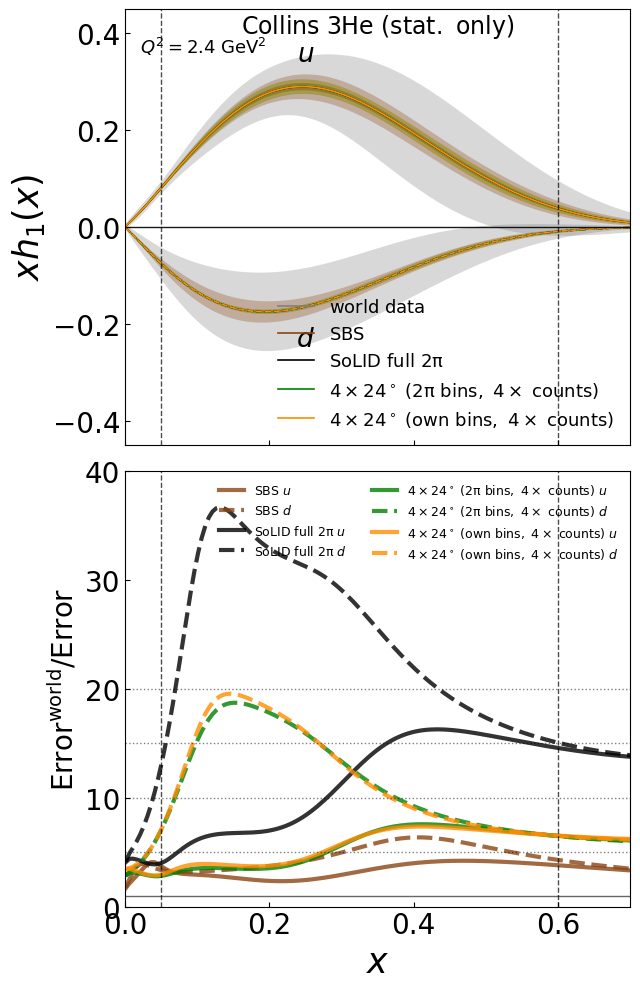

In [7]:
band_plot('', 'trans-phicompare.pdf',
          r'$\rm Collins~3He~(stat.~only)$');

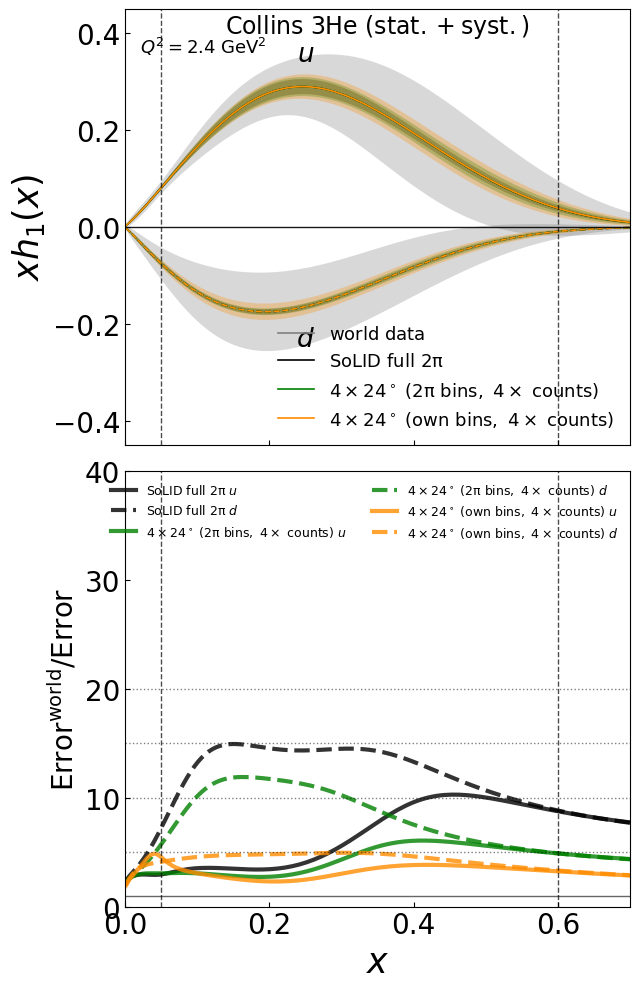

In [8]:
band_plot('syst', 'trans-phicompare-syst.pdf',
          r'$\rm Collins~3He~(stat.+syst.)$');

## Uncertainty ratio at representative $x$

Same information as the bottom panel above, tabulated at the $x$ values that
bracket the SoLID coverage (0.05–0.60).

In [9]:
XPTS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

rows = []
for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    ref = h1[Q2LIST[0]][REF + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        d = h1[Q2LIST[0]][run + suffix]
        for q, lab in [('Exu', 'u'), ('Exd', 'd')]:
            r = {'variant': sname, 'run': run, 'quark': lab}
            for x in XPTS:
                j = int(np.argmin(np.abs(d['x'].values - x)))
                r[f'x={x}'] = round(ref[q].values[j] / d[q].values[j], 2)
            rows.append(r)
ratios = pd.DataFrame(rows).set_index(['variant', 'run', 'quark'])
print('Error^world / Error  (larger = SoLID better; 20 means 20x more precise)')
ratios

Error^world / Error  (larger = SoLID better; 20 means 20x more precise)


x=0.05  x=0.1  x=0.2  x=0.3  x=0.4  x=0.5  \
variant   run                quark                                              
stat      sbs                u        3.67   2.92   2.35   2.94   3.96   4.18   
                             d        3.34   3.22   3.74   5.00   6.34   5.50   
          phifull            u        4.02   6.17   7.00  11.44  15.99  15.78   
                             d       13.26  32.46  32.80  28.93  22.10  17.41   
          phi4seg_fullbin_x4 u        2.82   3.51   3.53   5.70   7.53   7.14   
                             d        7.16  15.39  17.74  13.22   9.29   7.38   
          phi4seg_x4         u        2.96   3.90   3.75   5.81   7.34   7.01   
                             d        7.20  16.25  18.13  13.08   9.09   7.30   
stat+syst phifull            u        2.96   3.53   3.44   5.65   9.51  10.03   
                             d        7.34  13.30  14.51  14.49  13.35  10.72   
          phi4seg_fullbin_x4 u        3.05   3.05   2.74   4.37   6.03   5.61   
                             d        5.80  10.21  11.71  10.17   7.58   5.84   
          phi4seg_x4         u        4.48   3.05   2.30   3.04   3.81   3.64   
                             d        4.12   4.56   4.80   4.94   4.62   3.91   

                                    x=0.6  
variant   run                quark         
stat      sbs                u       3.80  
                             d       4.30  
          phifull            u      14.58  
                             d      15.07  
          phi4seg_fullbin_x4 u       6.50  
                             d       6.47  
          phi4seg_x4         u       6.52  
                             d       6.51  
stat+syst phifull            u       8.77  
                             d       8.84  
          phi4seg_fullbin_x4 u       4.89  
                             d       4.90  
          phi4seg_x4         u       3.23  
                             d       3.32

## $-h_1^d/h_1^u$

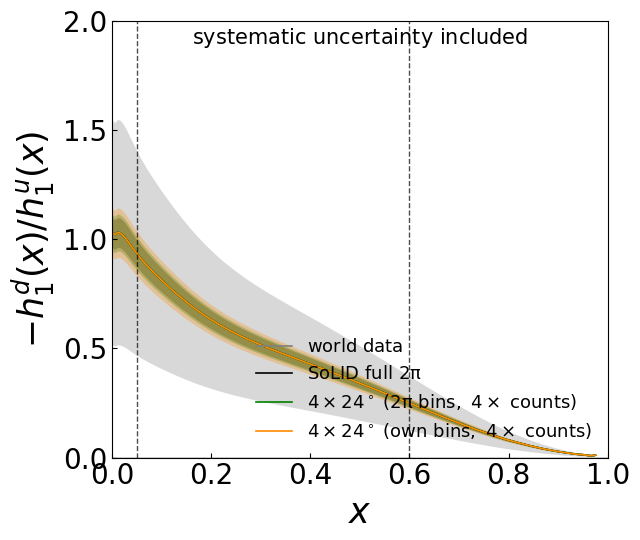

In [10]:
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(1, 1, 1)
for run, cfg in runs_for('syst'):          # SBS has no syst fit; it drops out here
    d = h1[Q2LIST[0]][run + 'syst']
    ax.fill_between(d['x'], -d['d/u'] - d['Ed/u'], -d['d/u'] + d['Ed/u'],
                    color=cfg['color'], alpha=0.30, linewidth=0)
    ax.plot(d['x'], -d['d/u'], color=cfg['color'], linewidth=1.2, label=cfg['label'])
ax.axhline(y=0, linestyle='-', color='black', alpha=0.9, linewidth=1)
ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
ax.set_xlabel(r'$x$', size=25)
ax.set_ylabel(r'$-h_1^d(x)/h_1^u(x)$', size=25)
ax.set_xlim(0, 1)
ax.set_ylim(0, 2)
ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
ax.text(0.5, 0.96, r'$\rm systematic~uncertainty~included$',
        horizontalalignment='center', verticalalignment='center',
        transform=ax.transAxes, fontsize=15)
ax.legend(loc='lower right', frameon=False, fontsize=13)
fig.tight_layout()
fig.savefig(f'{GALLERY}/trans-doveru-phicompare.pdf')

## Tensor charge $g_T$

`gtcalc` integrates over all $x$; `gttruncate` restricts to the measured range
$0.05 < x < 0.6$ — the truncated one is the honest comparison, since the full
integral extrapolates outside SoLID coverage.

`tmd.gt_fast` replaces `tmd.gt` here: fixed-node quadrature on a grid shared by
all replicas, ~780x faster and agreeing with `gt` to 4e-9 (truncated) and 4e-7
(full). `gt` remains the reference for one-off authoritative numbers.


In [11]:
def gtcalc(pset, Q2, tol, xl=None, xu=None):
    pset = pset.reset_index(drop=True)
    gu, gd, gt = [], [], []
    for i in range(len(pset)):
        tmp = tmd.gt_fast(Q2, pset.loc[i]) if xl is None else tmd.gt_fast(Q2, pset.loc[i], xl, xu)
        gu.append(tmp['u']); gd.append(tmp['d']); gt.append(tmp['u-d'])
    return {'u': np.mean(gu), 'Eu': np.std(gu) * tol,
            'd': np.mean(gd), 'Ed': np.std(gd) * tol,
            'u-d': np.mean(gt), 'Eu-d': np.std(gt) * tol}

gt  = {k: gtcalc(par[k], Q2, tol) for k in par}
gtt = {k: gtcalc(par[k], Q2, tol, 0.05, 0.6) for k in par}

In [12]:
rows = []
for k in par:
    rows.append({'run': k,
                 'gT(u)':  f"{gt[k]['u']:.4f} +- {gt[k]['Eu']:.4f}",
                 'gT(d)':  f"{gt[k]['d']:.4f} +- {gt[k]['Ed']:.4f}",
                 'gT(u-d)': f"{gt[k]['u-d']:.4f} +- {gt[k]['Eu-d']:.4f}",
                 'gT trunc (u-d)': f"{gtt[k]['u-d']:.4f} +- {gtt[k]['Eu-d']:.4f}"})
pd.DataFrame(rows).set_index('run')

,gT(u),gT(d),gT(u-d),gT trunc (u-d)
run,,,,
world,0.5475 +- 0.1175,-0.3766 +- 0.1715,0.9241 +- 0.2111,0.7654 +- 0.1701
worldsyst,0.5475 +- 0.1175,-0.3766 +- 0.1715,0.9241 +- 0.2111,0.7654 +- 0.1701
sbs,0.5462 +- 0.0409,-0.3760 +- 0.0417,0.9222 +- 0.0417,0.7656 +- 0.0395
phifull,0.5470 +- 0.0158,-0.3760 +- 0.0098,0.9230 +- 0.0200,0.7651 +- 0.0107
phifullsyst,0.5469 +- 0.0239,-0.3757 +- 0.0181,0.9225 +- 0.0274,0.7652 +- 0.0195
phi4seg_fullbin_x4,0.5470 +- 0.0248,-0.3759 +- 0.0183,0.9229 +- 0.0298,0.7652 +- 0.0197
phi4seg_fullbin_x4syst,0.5469 +- 0.0268,-0.3756 +- 0.0228,0.9225 +- 0.0304,0.7654 +- 0.0246
phi4seg_x4,0.5472 +- 0.0247,-0.3760 +- 0.0184,0.9232 +- 0.0333,0.7652 +- 0.0221
phi4seg_x4syst,0.5469 +- 0.0355,-0.3753 +- 0.0361,0.9222 +- 0.0514,0.7655 +- 0.0468


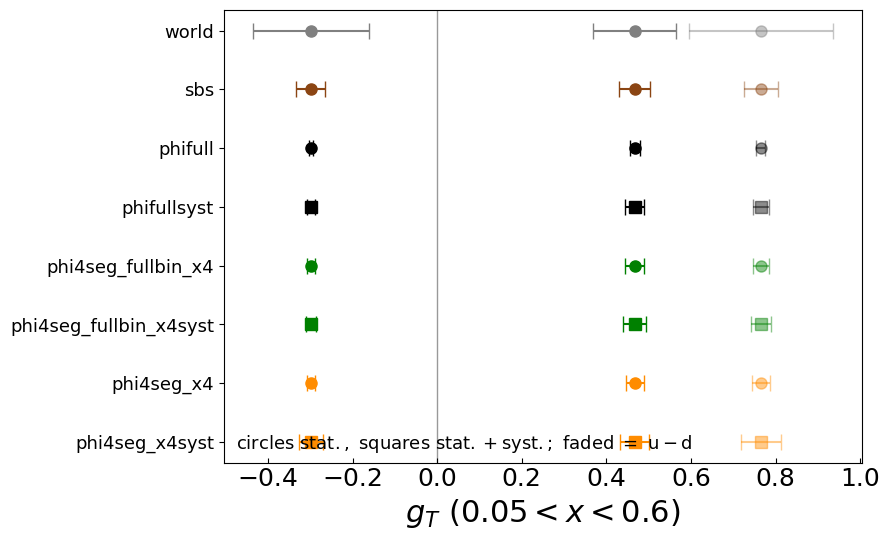

In [13]:
fig = plt.figure(figsize=(9, 5.5))
ax = fig.add_subplot(1, 1, 1)

ypos = {}
y = 0
for run, cfg in RUNS.items():
    for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
        if suffix not in cfg['files']:
            continue          # SBS is stat-only -- one row, in the stat block
        if run == REF and suffix == 'syst':
            continue          # world points both variants at the same fit
        key = run + suffix
        ypos[key] = y
        src = gtt[key]
        ls = 'o' if suffix == '' else 's'
        ax.errorbar(src['u'],   y, xerr=src['Eu'],   marker=ls, color=cfg['color'],
                    markersize=8, capsize=6)
        ax.errorbar(src['d'],   y, xerr=src['Ed'],   marker=ls, color=cfg['color'],
                    markersize=8, capsize=6)
        ax.errorbar(src['u-d'], y, xerr=src['Eu-d'], marker=ls, color=cfg['color'],
                    markersize=8, capsize=6, alpha=0.45)
        y -= 1

ax.set_yticks(list(ypos.values()))
ax.set_yticklabels(list(ypos.keys()), fontsize=13)
ax.set_xlabel(r'$g_T~(0.05<x<0.6)$', size=22)
ax.tick_params(axis='x', which='both', direction='in', labelsize=18)
ax.axvline(x=0, linestyle='-', color='black', alpha=0.4, linewidth=1)
ax.text(0.02, 0.03, r'$\rm circles~stat.,~squares~stat.+syst.;~faded~=~u-d$',
        transform=ax.transAxes, fontsize=13)
fig.tight_layout()
fig.savefig(f'{GALLERY}/gt-phicompare.pdf')

## Summary

Relative $g_T^{u-d}$ (truncated) uncertainty, normalised to **world** — the
single-number version of the whole comparison, and the one to quote for
"how much does SoLID improve on current knowledge".

In [14]:
for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    ref = gtt[REF + suffix]['Eu-d']
    print(f'--- {sname} ---')
    for run, cfg in runs_for(suffix):
        r = ref / gtt[run + suffix]['Eu-d']
        print(f"  {run:18s} E(gT u-d) = {gtt[run+suffix]['Eu-d']:.4f}"
              f"   world/this = {r:6.2f}x")

--- stat ---
  world              E(gT u-d) = 0.1701   world/this =   1.00x
  sbs                E(gT u-d) = 0.0395   world/this =   4.31x
  phifull            E(gT u-d) = 0.0107   world/this =  15.86x
  phi4seg_fullbin_x4 E(gT u-d) = 0.0197   world/this =   8.62x
  phi4seg_x4         E(gT u-d) = 0.0221   world/this =   7.71x
--- stat+syst ---
  world              E(gT u-d) = 0.1701   world/this =   1.00x
  phifull            E(gT u-d) = 0.0195   world/this =   8.71x
  phi4seg_fullbin_x4 E(gT u-d) = 0.0246   world/this =   6.90x
  phi4seg_x4         E(gT u-d) = 0.0468   world/this =   3.64x
